In [1]:
1+1

2

In [13]:
from __future__ import annotations

"""
Agent Graph

Flow:

START
  ↓
chat_node
  ↓
tools_condition
  ├── tools
  │      ↓
  │   chat_node
  │
  └── memory_check
           ↓
      ┌──────────────┐
      │ Should summary?│
      └──────┬───────┘
          YES│ NO
             │
      summarize_memory
             │
             ↓
            END
"""

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition

from app.graph.state import ChatState

from app.graph.nodes import (
    chat_node,
    tool_node,
)
from app.graph.fin_ans import final_answer_node

from app.memory.sqlite_memory import checkpointer
from app.memory.stm import summarize_memory

from app.utils.logger import get_logger


logger = get_logger(__name__)


# ============================================================
# MEMORY CONDITION
# ============================================================

MAX_MESSAGES_BEFORE_SUMMARY = 12


def should_summarize(state: ChatState):
    """
    Decide whether conversation memory should be summarized.

    If the number of messages becomes too large,
    summarize older messages.

    Otherwise end normally.
    """

    messages = state.get("messages", [])

    message_count = len(messages)

    logger.info(
        f"[MEMORY] Current message count: {message_count}"
    )

    print(
        f"[MEMORY] Current message count: {message_count}"
    )

    if message_count > MAX_MESSAGES_BEFORE_SUMMARY:

        logger.info(
            "[MEMORY] Conversation too large -> summarizing"
        )

        print(
            "[MEMORY] Conversation too large -> summarizing"
        )

        return "summarize_memory"

    logger.info(
        "[MEMORY] Conversation size OK -> END"
    )

    print(
        "[MEMORY] Conversation size OK -> END"
    )

    return "end"


def route_after_chat(state: ChatState):
    """
    First check whether the LLM requested a tool.

    If yes:
        go to tools

    If no:
        check conversation memory
    """

    result = tools_condition(state)

    if result == "tools":

        return "tools"

    return "memory_check"



def route_after_tools(state: ChatState):
    """
    Decide what happens after tool execution.

    unified_rag_tool:
        → final_answer

    Other tools:
        → chat_node
    """

    messages = state.get("messages", [])

    if not messages:
        return "chat_node"

    # Find the most recent ToolMessage
    for message in reversed(messages):

        if isinstance(message, ToolMessage):

            print(
                f"[ROUTER] Tool executed: {message.name}"
            )

            if message.name == "unified_rag_tool":

                print(
                    "[ROUTER] RAG tool detected → final_answer"
                )

                return "final_answer"

            print(
                "[ROUTER] Other tool detected → chat_node"
            )

            return "chat_node"

    return "chat_node"

# ============================================================
# GRAPH
# ============================================================

graph = StateGraph(ChatState)


# ============================================================
# NODES
# ============================================================

graph.add_node(
    "chat_node",
    chat_node
)

graph.add_node(
    "tools",
    tool_node
)

graph.add_node(
    "summarize_memory",
    summarize_memory
)

graph.add_node("final_answer",
               final_answer_node)

graph.add_node(
    "memory_check",
    lambda state: {}
)


# ============================================================
# START
# ============================================================

graph.add_edge(
    START,
    "chat_node"
)


# ============================================================
# CHAT NODE → TOOLS OR MEMORY CHECK
# ============================================================



graph.add_conditional_edges(
    "chat_node",
    route_after_chat,
    {
        "tools": "tools",
        "memory_check": "memory_check",
    }
)


# ============================================================
# TOOLS → CHAT NODE
# ============================================================

graph.add_conditional_edges(
    "tools",
    route_after_tools,
    {
        "final_answer": "final_answer",
        "chat_node": "chat_node",
    }
)

graph.add_edge(
    "final_answer",
    "memory_check"
)


# ============================================================
# MEMORY CHECK
# ============================================================


graph.add_conditional_edges(
    "memory_check",
    should_summarize,
    {
        "summarize_memory": "summarize_memory",
        "end": END,
    }
)


# ============================================================
# SUMMARY → END
# ============================================================

graph.add_edge(
    "summarize_memory",
    END
)


# ============================================================
# COMPILE
# ============================================================

chatbot = graph.compile(
    checkpointer=checkpointer
)

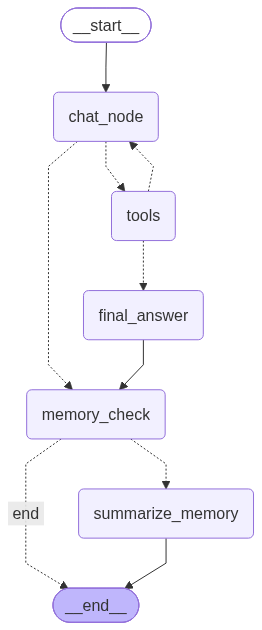

In [14]:
from IPython.display import Image,display
display(Image(chatbot.get_graph().draw_mermaid_png()))